# Carga de datos

In [1]:
import pyreadr
import pandas as pd

# Cargar el archivo .RData
resultados = pyreadr.read_r('nacXanioMes.RData')


# Extraer el DataFrame
df = resultados['nacXanioMes']


# Exploracion de Datos

In [4]:
# Convertir 'Anio' a entero

print(df.head())
df['Anio'] = pd.to_numeric(df['Anio'], errors='coerce')
df = df.dropna(subset=['Anio'])
df['Anio'] = df['Anio'].astype(int)

# Mostrar último año disponible
ultimo_anio = df['Anio'].max()
print("Último año disponible:", ultimo_anio)

   Anio Mes  Cantidad
0  2009   1     30715
1  2010   1     30671
2  2011   1     30766
3  2012   1     33127
4  2013   1     33130
Último año disponible: 2022


# Dividir los datos

In [3]:

# Dividir en conjuntos de entrenamiento y prueba
df_train = df[(df['Anio'] >= 2009) & (df['Anio'] <= 2019)]
df_test  = df[(df['Anio'] >= 2020) & (df['Anio'] <= 2022)]

# Mostrar tamaños
print("Tamaño del conjunto de entrenamiento:", len(df_train))
print("Tamaño del conjunto de prueba:", len(df_test))



Tamaño del conjunto de entrenamiento: 132
Tamaño del conjunto de prueba: 36


## Graficar sin Log 

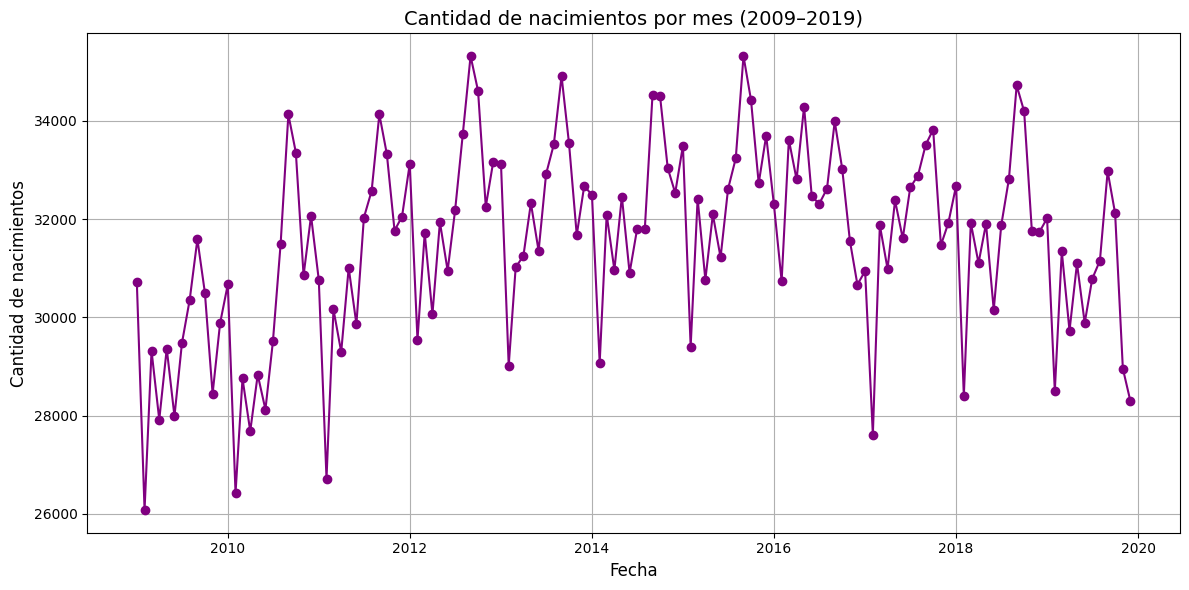

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_train['Fecha'] = pd.to_datetime(df_train['Anio'].astype(str) + '-' + df_train['Mes'].astype(str).str.zfill(2) + '-01')



df_train = df_train.sort_values('Fecha')

plt.figure(figsize=(12, 6))
plt.plot(df_train['Fecha'], df_train['Cantidad'], marker='o', linestyle='-', color='purple')

plt.title('Cantidad de nacimientos por mes (2009–2019)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de nacimientos', fontsize=12)
plt.grid(True)
plt.tight_layout()

plt.show()


## Graficar con Log

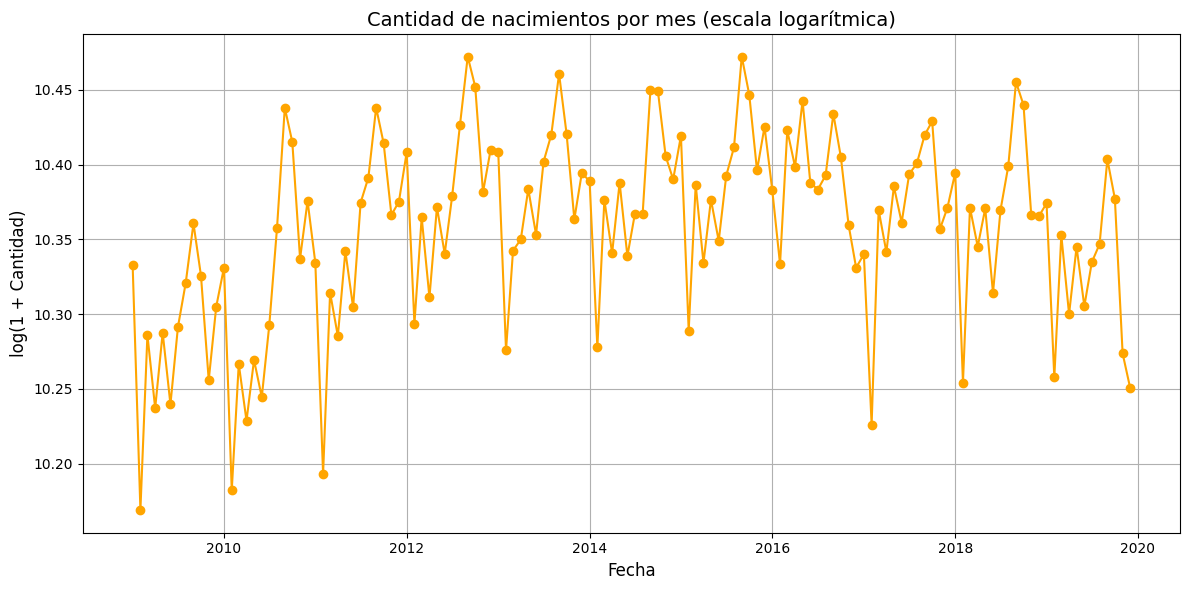

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_train['Fecha'] = pd.to_datetime(df_train['Anio'].astype(str) + '-' + df_train['Mes'].astype(str).str.zfill(2) + '-01')

df_train['Cantidad_log'] = df_train['Cantidad'].apply(lambda x: np.log1p(x))  # log(1 + x)


plt.figure(figsize=(12, 6))
plt.plot(df_train['Fecha'], df_train['Cantidad_log'], marker='o', linestyle='-', color='orange')

plt.title('Cantidad de nacimientos por mes (escala logarítmica)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('log(1 + Cantidad)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()
